<a href="https://www.kaggle.com/code/bavlywaleed/deep-q-network-dqn-space-invaders?scriptVersionId=305407289" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 👾 Deep Q-Network (DQN): Teaching AI to Play Space Invaders
### Reinforcement Learning in Action — Episode 4

---

> *"Q-Learning worked perfectly on 48 states. Space Invaders has 33,600 pixels per frame. You can't build a Q-table for that — you need a neural network."*

This notebook implements **DQN** — the algorithm DeepMind used in 2013 to beat human-level performance on 49 Atari games using nothing but raw pixels — built from scratch with Keras on **Space Invaders**.

By the end you'll understand all 4 components that make DQN work:
- 🧠 **DNN replacing the Q-table** — neural network approximates Q(s,a)
- 🎲 **Experience Replay** — random sampling from memory stabilizes training
- 🎯 **Fixed Q-Targets** — two networks prevent chasing a moving target
- 👁️ **CNN for visual input** — convolutional layers extract features from pixels

---

## 📋 Table of Contents
### 🧠 Theory
1. [Why Q-Learning Breaks at Scale](#section1)
2. [The 4 DQN Components — Deep Dive](#section2)
3. [DeepMind's Original Architecture (2013)](#section3)

### 🔨 Implementation
4. [Setup](#section5)
5. [Pixel Preprocessing Pipeline](#section12)
6. [Building the DQN Agent (CNN)](#section13)
7. [Training & Tracking Progress](#section14)

### 📊 Results
8. [Visualizing Training](#section15)
9. [Watching the Agent Play (Video)](#section16)
10. [Key Takeaways & What's Next](#section18)

---
<a id='section1'></a>
## 💥 Section 1 — Why Q-Learning Breaks at Scale

In Episodes 1–3, our environments had tiny, discrete state spaces:
- FrozenLake: **16 states** → Q-table: 16×4 = 64 numbers ✅
- CliffWalking: **48 states** → Q-table: 48×4 = 192 numbers ✅

Now consider Space Invaders:

| Input type | State space size | Q-table size |
|---|---|---|
| RAM (128 bytes) | 256^128 ≈ 10^308 states | Impossible |
| Pixels (210×160×3) | 256^(210×160×3) ≈ 10^121,000 states | Impossible |

**The solution**: Don't store Q(s,a) — **approximate** it with a neural network:

```
Q-table:   Q(s, a) = table[s][a]         ← exact lookup, needs every state

DQN:       Q(s, a) ≈ Network(s; θ)[a]    ← neural net generalizes across states
                     Input: state s
                     Output: Q-value for EACH action simultaneously
```

The network **generalizes** — two similar states get similar Q-values, even if neither was seen during training. This is the core insight that makes Deep RL possible.

---
<a id='section2'></a>
## 🔧 Section 2 — The 4 DQN Components — Deep Dive

### Component 1 — Neural Network Replacing the Q-Table

The **DQN loss function** (what we minimize with gradient descent):

$$\mathcal{L}(\theta) = \mathbb{E}\left[\left(\underbrace{r + \gamma \cdot \max_{a'} Q(s', a'; \theta^-)}_{\text{target }y \text{ — uses frozen weights}} - \underbrace{Q(s, a; \theta)}_{\text{prediction}}\right)^2\right]$$

We use **Huber loss** instead of raw MSE — it behaves like MSE for small errors but clips large errors (like the -100 cliff penalty), preventing the network from being destabilized by rare catastrophic events.

---

### Component 2 — Experience Replay 🎲

**Problem**: Without replay, the agent trains on consecutive frames:
```
frame_t → frame_t+1 → frame_t+2  ← highly correlated, network overfits
```

**Solution**: Store all transitions in a buffer, sample randomly:
```
┌──────────────────────────────────────────────────────┐
│  REPLAY BUFFER  (capacity: 50,000 transitions)       │
│  (s₁, a₁, r₁, s₁', done) ← gets overwritten oldest  │
│  (s₂, a₂, r₂, s₂', done)                            │
│  ...                  Random sample batch of 32 ───► Train
│  (sₙ, aₙ, rₙ, sₙ', done) ← newest                  │
└──────────────────────────────────────────────────────┘
```

Benefits:
1. **Breaks correlation** — random batch ≈ i.i.d. samples
2. **Data efficiency** — each experience reused multiple times
3. **Stable gradients** — network sees diverse mix of old & new

---

### Component 3 — Fixed Q-Targets 🎯

**Problem**: Both prediction AND target use the same weights θ:
$$\mathcal{L} = (r + \gamma \cdot \max_{a'} \underbrace{Q(s', a'; \theta)}_{\text{moves every step!}} - Q(s, a; \theta))^2$$

Every gradient step changes θ → target changes → chasing a moving bullseye → training diverges.

**Solution**: Two networks with **different update frequencies**:
```
ONLINE network  θ    — updated every step via gradient descent
TARGET network  θ⁻   — frozen copy of θ, updated every 1000 steps

Loss: L = (r + γ·max Q(s', a'; θ⁻) - Q(s, a; θ))²
                              ↑
                    θ⁻ is frozen — stable target!
```

---

### Component 4 — ε-greedy with Decay

Same as Q-Learning/SARSA but with **slower decay** — the network needs more exploration steps to learn from scratch:
```
ε = 1.0 → explore 100% (random actions)
ε = 0.05 → exploit 95% (best action), explore 5%
```

---
<a id='section3'></a>
## 📄 Section 3 — DeepMind's Original Architecture (2013)

From *"Playing Atari with Deep Reinforcement Learning"* (Mnih et al., 2013):

```
Input:  84×84×4  (4 stacked grayscale frames)
   ↓
Conv2D  16 filters, 8×8, stride 4, ReLU   → 20×20×16
   ↓
Conv2D  32 filters, 4×4, stride 2, ReLU   → 9×9×32
   ↓
Flatten → Dense 256, ReLU
   ↓
Dense n_actions, Linear   (Q-value per action)

Optimizer:    RMSprop, lr=0.00025
Replay:       1,000,000 transitions
Target sync:  every 10,000 steps
Training:     50,000,000 frames (~1 week on GPU)
```

The 2015 upgrade (Nature paper) added a 3rd Conv layer and trained to **beat humans on 49 games**.

### Why We Build Two Lighter Versions

| | DeepMind 2013 | Our RAM DQN | Our CNN DQN |
|---|---|---|---|
| Input | 84×84×4 pixels | 128 RAM bytes | 84×84×4 pixels |
| Replay buffer | 1M | 10K | 50K |
| Training | 50M frames | ~100K | ~200K |
| Time | ~1 week | ~20 min (CPU) | ~1-2h (GPU) |
| Goal | Human-level | Demonstrate mechanics | Demonstrate CNN |

In [1]:
!pip install gymnasium[atari] ale-py keras tensorflow --quiet
!pip install "gymnasium[other]" --quiet 2>/dev/null; true

In [2]:
import numpy as np
import gymnasium as gym
import ale_py
gym.register_envs(ale_py)   # ← registers ALE/SpaceInvaders-* and all Atari envs

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from collections import deque
import random, time, cv2
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML, clear_output
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

gpus = tf.config.list_physical_devices('GPU')
print("✅ Libraries ready!")
print(f"   TensorFlow: {tf.__version__}")
print(f"   ALE registered: {len([e for e in gym.envs.registry if 'SpaceInvaders' in e])} SpaceInvaders variants")
print(f"   GPU: {'✅ ' + gpus[0].name if gpus else '❌ CPU only — Part 1 (RAM) still runs fine!'}")

2026-03-21 16:08:24.900599: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774109305.147894      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774109305.221742      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774109305.808609      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774109305.808725      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774109305.808731      17 computation_placer.cc:177] computation placer alr

✅ Libraries ready!
   TensorFlow: 2.19.0
   ALE registered: 5 SpaceInvaders variants
   GPU: ❌ CPU only — Part 1 (RAM) still runs fine!


2026-03-21 16:08:56.862456: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


---
<a id='section11'></a>
## 👁️ Section 4 — Why CNN? Visual Feature Extraction Explained

A regular Dense layer treats pixels as **independent numbers** — it has no concept of spatial relationships. A CNN preserves spatial structure.

```
Dense layer:   [p₁, p₂, p₃, ..., p₃₃₆₀₀]  — flat, ignores position

CNN:            ┌─────────────────────┐
                │ █ █ · · · · · · · │  ← filter slides across image
                │ █ █ · · · · · · · │    detects local patterns
                │ · · · · · · · · · │
                └─────────────────────┘
```

### What Each CNN Layer Learns

```
Input: 84×84×4 (4 stacked grayscale frames)
       ↓
Conv2D(32, 8×8, stride=4)  → detects edges, corners        → 20×20×32
       ↓
Conv2D(64, 4×4, stride=2)  → detects objects (ship, aliens) → 9×9×64
       ↓
Flatten → Dense(512)       → combines spatial features
       ↓
Dense(n_actions)           → Q-value per action
```

### Frame Stacking — Temporal Information

A single frame can't tell the agent: are aliens moving left or right? Is a bullet traveling up?

We stack 4 consecutive frames → the network sees **motion implicitly**:
```
Stack = [frame_t-3, frame_t-2, frame_t-1, frame_t]  → (84, 84, 4)
```

---
<a id='section12'></a>
## 🖼️ Section 12 — Pixel Preprocessing Pipeline

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


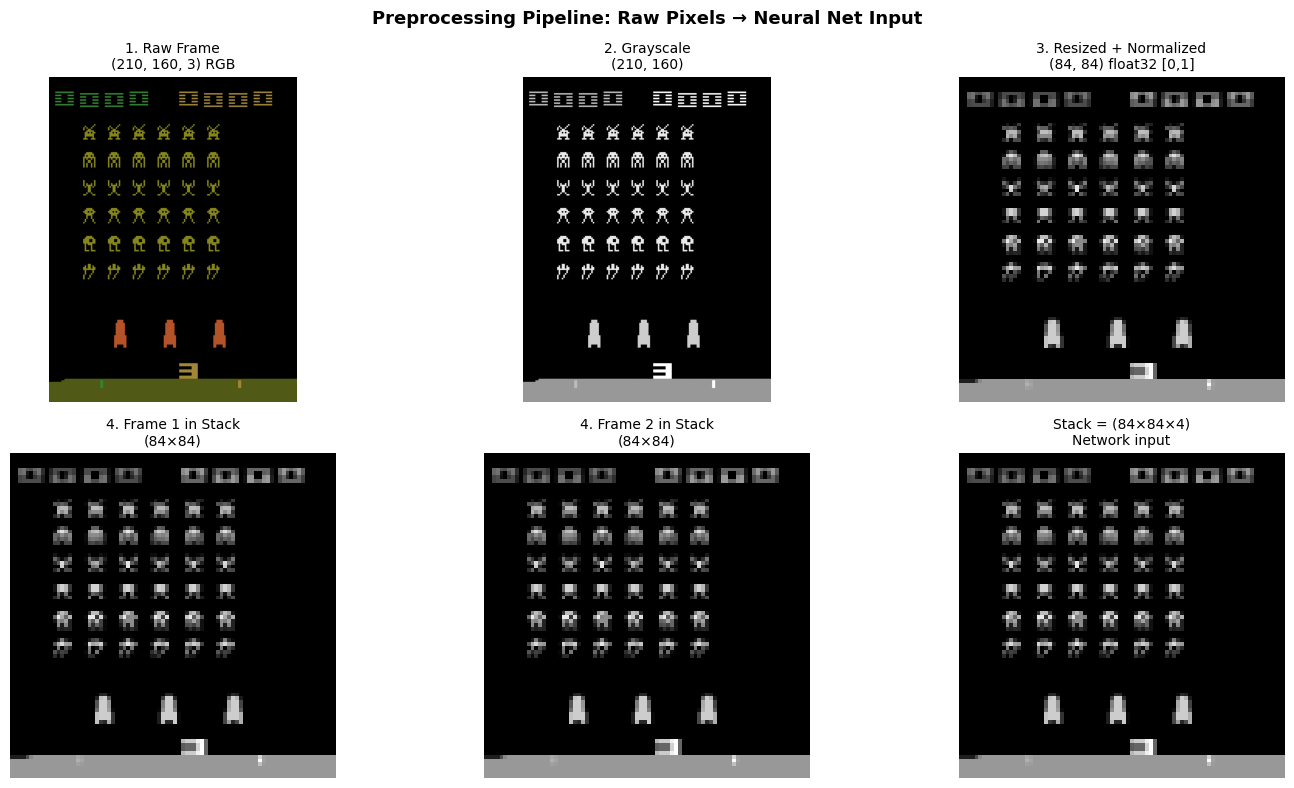

✅ State shape: (84, 84, 4)
📊 Saved: preprocessing.png


In [3]:
# ── Preprocessing constants ───────────────────────────────────────────────────
FRAME_H    = 84
FRAME_W    = 84
STACK_SIZE = 4


def preprocess_frame(frame):
    """210×160×3 RGB → 84×84 grayscale float32 in [0,1]"""
    gray    = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    resized = cv2.resize(gray, (FRAME_W, FRAME_H), interpolation=cv2.INTER_AREA)
    return resized.astype(np.float32) / 255.0


class FrameStack:
    """Rolling stack of the last STACK_SIZE preprocessed frames → (84,84,4) state"""
    def __init__(self, k=STACK_SIZE):
        self.k = k
        self.frames = deque(maxlen=k)

    def reset(self, frame):
        p = preprocess_frame(frame)
        self.frames.clear()
        [self.frames.append(p) for _ in range(self.k)]
        return np.stack(self.frames, axis=-1)

    def step(self, frame):
        self.frames.append(preprocess_frame(frame))
        return np.stack(self.frames, axis=-1)


# ── Visualize pipeline ────────────────────────────────────────────────────────
env_pix = gym.make('ALE/SpaceInvaders-v5', render_mode='rgb_array')
obs_p, _ = env_pix.reset()
stk = FrameStack()
state_p = stk.reset(obs_p)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0,0].imshow(obs_p)
axes[0,0].set_title(f'1. Raw Frame\n{obs_p.shape} RGB', fontsize=10)
axes[0,0].axis('off')

gray = cv2.cvtColor(obs_p, cv2.COLOR_RGB2GRAY)
axes[0,1].imshow(gray, cmap='gray')
axes[0,1].set_title(f'2. Grayscale\n{gray.shape}', fontsize=10)
axes[0,1].axis('off')

proc = preprocess_frame(obs_p)
axes[0,2].imshow(proc, cmap='gray')
axes[0,2].set_title(f'3. Resized + Normalized\n{proc.shape} float32 [0,1]', fontsize=10)
axes[0,2].axis('off')

for i in range(4):
    ax = axes[1, i] if i < 3 else axes[1, 2]  # reuse last slot
    if i < 3:
        axes[1,i].imshow(state_p[:,:,i], cmap='gray')
        axes[1,i].set_title(f'4. Frame {i+1} in Stack\n(84×84)', fontsize=10)
        axes[1,i].axis('off')

axes[1,2].set_title(f'Stack = (84×84×4)\nNetwork input', fontsize=10)

plt.suptitle('Preprocessing Pipeline: Raw Pixels → Neural Net Input',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('preprocessing.png', dpi=150, bbox_inches='tight')
plt.show()
env_pix.close()
print(f"✅ State shape: {state_p.shape}")
print("📊 Saved: preprocessing.png")

In [4]:
# ReplayBuffer
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def add(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, ns, d = zip(*batch)
        return (np.array(s,  dtype=np.float32),
                np.array(a,  dtype=np.int32),
                np.array(r,  dtype=np.float32),
                np.array(ns, dtype=np.float32),
                np.array(d,  dtype=np.float32))

    def __len__(self):
        return len(self.buffer)

print("✅ ReplayBuffer defined  [Component 2: Experience Replay]")


✅ ReplayBuffer defined  [Component 2: Experience Replay]


In [5]:
# DQNAgent — all 4 components
class DQNAgent:
    def __init__(self, model_fn, state_shape, n_actions,
                 gamma=0.99, epsilon=1.0, epsilon_min=0.05,
                 epsilon_decay=0.995, buffer_cap=50_000,
                 batch_size=32, target_update_freq=1_000,
                 min_replay=1_000):
        self.n_actions          = n_actions
        self.gamma              = gamma
        self.epsilon            = epsilon
        self.epsilon_min        = epsilon_min
        self.epsilon_decay      = epsilon_decay
        self.batch_size         = batch_size
        self.target_update_freq = target_update_freq
        self.min_replay         = min_replay
        self.step_count         = 0
        self.replay  = ReplayBuffer(buffer_cap)          # Component 2
        self.online  = model_fn(state_shape, n_actions)  # Component 1+4
        self.target  = model_fn(state_shape, n_actions)  # Component 3
        self.target.set_weights(self.online.get_weights())

    def act(self, state, greedy=False):
        if not greedy and np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)   # explore
        q = self.online.predict(state[np.newaxis], verbose=0)
        return int(np.argmax(q[0]))                    # exploit

    def store(self, s, a, r, ns, done):
        self.replay.add(s, a, r, ns, done)

    def train_step(self):
        if len(self.replay) < self.min_replay:
            return None, False
        # Component 2: random sample — breaks temporal correlation
        s, a, r, ns, d = self.replay.sample(self.batch_size)
        # Component 3: targets use FROZEN target network
        next_q  = self.target.predict(ns, verbose=0)
        targets = r + self.gamma * np.max(next_q, axis=1) * (1 - d)
        # Update only the Q-value of the action that was taken
        current_q = self.online.predict(s, verbose=0)
        for i, action in enumerate(a):
            current_q[i, action] = targets[i]
        loss = self.online.train_on_batch(s, current_q)
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
        self.step_count += 1
        # Component 3: sync online → target every C steps
        updated = (self.step_count % self.target_update_freq == 0)
        if updated:
            self.target.set_weights(self.online.get_weights())
        return loss, updated

    def get_policy_action(self, state):
        q = self.online.predict(state[np.newaxis], verbose=0)
        return int(np.argmax(q[0]))

print("✅ DQNAgent defined — all 4 components integrated:")
print("   Component 1+4: CNN online_net  →  approximates Q(s,a)")
print("   Component 2:   ReplayBuffer   →  random sampling")
print("   Component 3:   target_net     →  frozen, synced every C steps")


✅ DQNAgent defined — all 4 components integrated:
   Component 1+4: CNN online_net  →  approximates Q(s,a)
   Component 2:   ReplayBuffer   →  random sampling
   Component 3:   target_net     →  frozen, synced every C steps


---
<a id='section13'></a>
## 🏗️ Section 13 — Building the CNN Agent

In [6]:
def build_cnn(input_shape, n_actions, lr=0.00025):
    """
    DQN CNN — inspired by DeepMind 2013, lighter for Kaggle.
    input_shape: (84, 84, 4)
    n_actions:   6
    """
    inputs = keras.Input(shape=input_shape)

    # Conv Block 1: detect edges and basic shapes
    x = layers.Conv2D(32, (8,8), strides=(4,4), activation='relu', name='conv1')(inputs)

    # Conv Block 2: detect objects (ship, aliens, bullets)
    x = layers.Conv2D(64, (4,4), strides=(2,2), activation='relu', name='conv2')(x)

    # Combine spatial features
    x = layers.Flatten()(x)
    x = layers.Dense(512, activation='relu', name='dense')(x)

    # Output: Q-value per action (linear — no activation)
    out = layers.Dense(n_actions, activation='linear', name='q_values')(x)

    model = keras.Model(inputs, out)
    model.compile(optimizer=keras.optimizers.Adam(lr),
                  loss=keras.losses.Huber())
    return model


# Show architecture + compare to RAM DNN
cnn_test = build_cnn((FRAME_H, FRAME_W, STACK_SIZE), 6)
cnn_test.summary()
del cnn_test

print()
print("📐 Architecture comparison:")
print(f"   RAM DNN:  Input(128) → Dense(128) → Dense(64) → Dense(6)")
print(f"   CNN:      Input(84×84×4) → Conv(32,8×8) → Conv(64,4×4) → Flatten → Dense(512) → Dense(6)")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 84, 84, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 20, 20, 32)     │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 9, 9, 64)       │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5184)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,654,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ q_values (Dense)                │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,698,854 (10.30 MB)

 Trainable params: 2,698,854 (10.30 MB)

 Non-trainable params: 0 (0.00 B)


📐 Architecture comparison:
   RAM DNN:  Input(128) → Dense(128) → Dense(64) → Dense(6)
   CNN:      Input(84×84×4) → Conv(32,8×8) → Conv(64,4×4) → Flatten → Dense(512) → Dense(6)


---
<a id='section14'></a>
## 🏋️ Section 14 — Training the CNN Agent

> ⚠️ With GPU (P100): ~1-2 hours. Without GPU: ~4-6 hours.

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# HYPERPARAMETERS — CNN DQN
# ══════════════════════════════════════════════════════════════════════════════
CNN_EPISODES      = 200
CNN_GAMMA         = 0.99
CNN_EPS_START     = 1.0
CNN_EPS_MIN       = 0.05
CNN_EPS_DECAY     = 0.9995
CNN_BUFFER_CAP    = 50_000
CNN_BATCH_SIZE    = 32
CNN_TARGET_UPDATE = 1_000
CNN_MIN_REPLAY    = 1_000

# ══════════════════════════════════════════════════════════════════════════════
# INITIALIZE FRESH
# ══════════════════════════════════════════════════════════════════════════════
env_cnn = gym.make('ALE/SpaceInvaders-v5', render_mode='rgb_array')
n_actions_cnn = env_cnn.action_space.n

np.random.seed(42); tf.random.set_seed(42); random.seed(42)

cnn_agent = DQNAgent(
    model_fn         = lambda shape, n: build_cnn(shape, n, lr=0.00025),
    state_shape      = (FRAME_H, FRAME_W, STACK_SIZE),
    n_actions        = n_actions_cnn,
    gamma            = CNN_GAMMA,
    epsilon          = CNN_EPS_START,
    epsilon_min      = CNN_EPS_MIN,
    epsilon_decay    = CNN_EPS_DECAY,
    buffer_cap       = CNN_BUFFER_CAP,
    batch_size       = CNN_BATCH_SIZE,
    target_update_freq = CNN_TARGET_UPDATE,
    min_replay       = CNN_MIN_REPLAY
)

# ══════════════════════════════════════════════════════════════════════════════
# TRAINING LOOP
# ══════════════════════════════════════════════════════════════════════════════
cnn_history = {'rewards': [], 'lengths': [], 'losses': [],
               'epsilon': [], 'target_updates': []}

print(f"🏋️  Training CNN DQN on Pixel SpaceInvaders for {CNN_EPISODES} episodes...")
print(f"   GPU: {'✅ Active' if tf.config.list_physical_devices('GPU') else '❌ CPU only — will be slow'}")
t0 = time.time()

stk_train = FrameStack()

for ep in range(CNN_EPISODES):
    obs, _ = env_cnn.reset()
    state  = stk_train.reset(obs)
    done   = False
    ep_r, ep_steps, ep_losses = 0, 0, []

    while not done:
        action = cnn_agent.act(state)
        next_obs, reward, term, trunc, _ = env_cnn.step(action)
        done = term or trunc
        next_state = stk_train.step(next_obs)

        cnn_agent.store(state, action, np.clip(reward, -1, 1), next_state, done)
        loss, synced = cnn_agent.train_step()
        if loss is not None:
            ep_losses.append(loss)
        if synced:
            cnn_history['target_updates'].append(ep)

        ep_r += reward; ep_steps += 1; state = next_state

    cnn_history['rewards'].append(ep_r)
    cnn_history['lengths'].append(ep_steps)
    cnn_history['losses'].append(np.mean(ep_losses) if ep_losses else 0)
    cnn_history['epsilon'].append(cnn_agent.epsilon)

    if (ep + 1) % 20 == 0:
        avg_r = np.mean(cnn_history['rewards'][-20:])
        elapsed = (time.time()-t0)/60
        print(f"  Ep {ep+1:3d}/{CNN_EPISODES} | Avg Reward: {avg_r:7.1f} | "
              f"ε: {cnn_agent.epsilon:.3f} | Steps: {cnn_agent.step_count:6d} | "
              f"Buffer: {len(cnn_agent.replay):5d} | Time: {elapsed:.1f}min")

print(f"\n✅ CNN DQN trained in {(time.time()-t0)/60:.1f} min")
print(f"   Final avg reward (last 20): {np.mean(cnn_history['rewards'][-20:]):.1f}")

🏋️  Training CNN DQN on Pixel SpaceInvaders for 200 episodes...
   GPU: ❌ CPU only — will be slow
  Ep  20/200 | Avg Reward:   146.0 | ε: 0.050 | Steps:   9667 | Buffer: 10666 | Time: 46.8min
  Ep  40/200 | Avg Reward:   166.2 | ε: 0.050 | Steps:  20696 | Buffer: 21695 | Time: 103.3min
  Ep  60/200 | Avg Reward:   195.5 | ε: 0.050 | Steps:  31138 | Buffer: 32137 | Time: 157.1min
  Ep  80/200 | Avg Reward:   239.2 | ε: 0.050 | Steps:  42537 | Buffer: 43536 | Time: 216.5min
  Ep 100/200 | Avg Reward:   257.8 | ε: 0.050 | Steps:  54281 | Buffer: 50000 | Time: 277.0min
  Ep 120/200 | Avg Reward:   222.0 | ε: 0.050 | Steps:  65574 | Buffer: 50000 | Time: 335.6min
  Ep 140/200 | Avg Reward:   235.8 | ε: 0.050 | Steps:  77737 | Buffer: 50000 | Time: 398.4min
  Ep 160/200 | Avg Reward:   275.8 | ε: 0.050 | Steps:  88975 | Buffer: 50000 | Time: 456.1min
  Ep 180/200 | Avg Reward:   229.0 | ε: 0.050 | Steps: 100609 | Buffer: 50000 | Time: 516.6min
  Ep 200/200 | Avg Reward:   192.2 | ε: 0.050 | 

---
<a id='section15'></a>
## 🔬 Section 15 — Visualizing What the CNN Learned

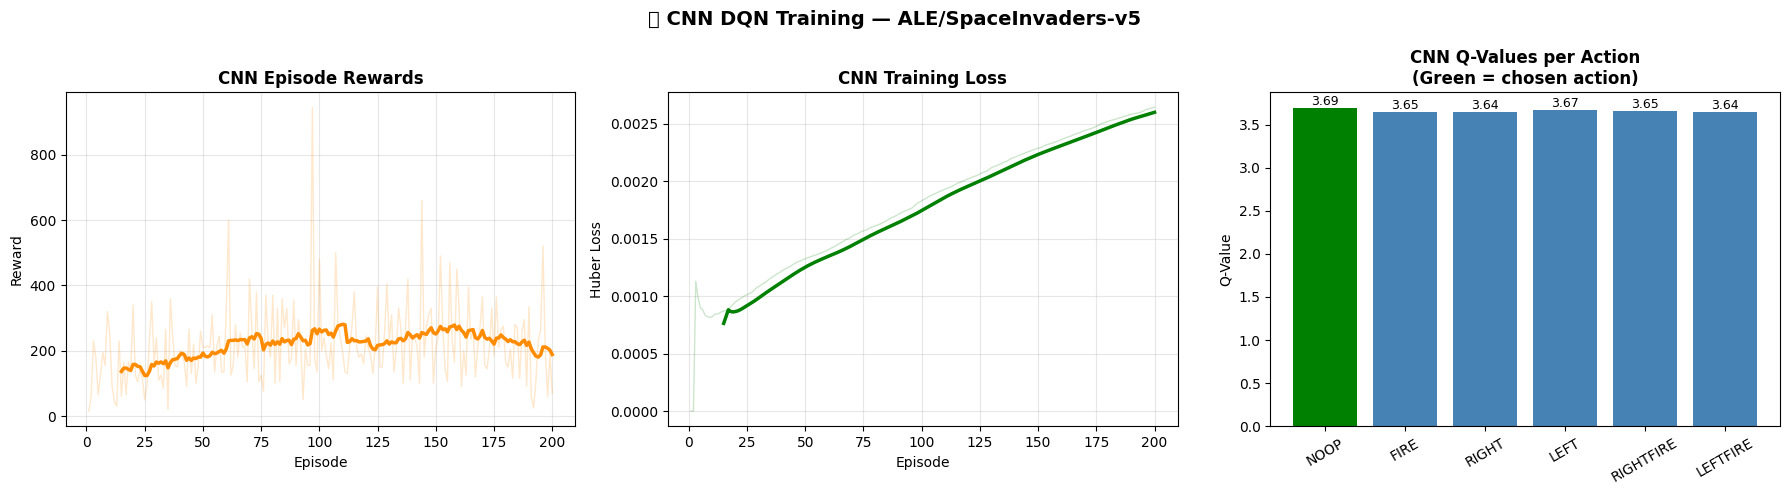

📊 Saved: cnn_training.png


In [8]:

# --- Helper function for smoothing curves ---
def smooth(data, window=15):
    if len(data) < window: return np.array(data)
    return np.convolve(data, np.ones(window)/window, mode='valid')

# --- Training curves plotting ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
w = 15

plot_configs = [
    (axes[0], cnn_history['rewards'],  'darkorange', 'Rewards'),
    (axes[1], cnn_history['losses'],   'green',      'Loss'),
]

for ax, hist, color, label in plot_configs:
    if not hist: continue
    eps_r = range(1, len(hist) + 1)
    ax.plot(eps_r, hist, alpha=0.2, color=color, lw=1)
    
    if len(hist) >= w:
        smoothed_vals = smooth(hist, w)
        # Adjust x-axis to match the valid convolution output
        ax.plot(range(w, len(smoothed_vals) + w), smoothed_vals, color=color, lw=2.5)
    ax.grid(True, alpha=0.3)

axes[0].set_title('CNN Episode Rewards', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Reward')

axes[1].set_title('CNN Training Loss', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Huber Loss')

# --- Q-values for a sample frame ---
env_viz = gym.make('ALE/SpaceInvaders-v5', render_mode='rgb_array')
obs_v, _ = env_viz.reset()
stk_v = FrameStack()
state_v = stk_v.reset(obs_v)

# Check if model is stored in .model or .online
try:
    q_vals = cnn_agent.model.predict(state_v[np.newaxis], verbose=0)[0]
except AttributeError:
    q_vals = cnn_agent.online.predict(state_v[np.newaxis], verbose=0)[0]

meanings = env_viz.unwrapped.get_action_meanings()
env_viz.close()

ax = axes[2]
colors_bar = ['green' if q == max(q_vals) else 'steelblue' for q in q_vals]
bars = ax.bar(meanings, q_vals, color=colors_bar)
ax.set_title('CNN Q-Values per Action\n(Green = chosen action)', fontsize=12, fontweight='bold')
ax.set_ylabel('Q-Value')
ax.tick_params(axis='x', rotation=30)

for bar, val in zip(bars, q_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('🟠 CNN DQN Training — ALE/SpaceInvaders-v5', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cnn_training.png', dpi=150, bbox_inches='tight')
plt.show()

print("📊 Saved: cnn_training.png")

---
<a id='section16'></a>
## 🎬 Section 16 — Watching the CNN Agent Play

In [9]:
def run_episode(agent, env_id):
    """Runs a full greedy episode and records frames"""
    env = gym.make(env_id, render_mode='rgb_array')
    stk = FrameStack()
    obs, _ = env.reset()
    state = stk.reset(obs)
    done = False
    frames = []
    total_reward = 0
    steps = 0
    
    while not done:
        frames.append(env.render())
        # Predict Q-values and pick the best action (greedy)
        try:
            q_values = agent.model.predict(state[np.newaxis], verbose=0)
        except AttributeError:
            q_values = agent.online.predict(state[np.newaxis], verbose=0)
            
        action = np.argmax(q_values[0])
        next_obs, reward, term, trunc, _ = env.step(action)
        state = stk.step(next_obs)
        total_reward += reward
        steps += 1
        done = term or trunc
        if steps > 2500: break # Safety cap
        
    env.close()
    return frames, total_reward, steps

print("🎬 Running greedy episode...")
cnn_frames, cnn_reward, cnn_steps = run_episode(cnn_agent, 'ALE/SpaceInvaders-v5')
print(f"   Steps: {cnn_steps} | Total reward: {cnn_reward}")

# Downsample frames for faster rendering (every 3rd frame)
frames_sub = cnn_frames[::3]
fig, ax = plt.subplots(figsize=(5, 7))
ax.axis('off')
img = ax.imshow(frames_sub[0])

def update_cnn(i):
    img.set_data(frames_sub[i])
    # Added \n for proper multi-line title formatting
    ax.set_title(f"🟠 CNN DQN Agent (Pixel Input)\nFrame ~{i*3}/{cnn_steps} | Score: {cnn_reward}",
                 fontsize=11, pad=8)
    return [img]

anim_cnn = animation.FuncAnimation(fig, update_cnn, frames=len(frames_sub),
                                    interval=80, blit=True, repeat=False)

plt.tight_layout()
plt.close() # Prevents showing an empty static plot
HTML(anim_cnn.to_jshtml())

🎬 Running greedy episode...
   Steps: 457 | Total reward: 110.0


---
<a id='section18'></a>
## 🎓 Section 18 — Key Takeaways & What's Next

### 🔑 The 4 DQN Components — Final Summary

| Component | Problem | Solution | Code |
|---|---|---|---|
| **DNN / CNN** | Q-table can't scale | Neural network approximates Q(s,a) | `build_dnn()` / `build_cnn()` |
| **Experience Replay** | Correlated frames → overfitting | Random sample from buffer of 10K–50K | `ReplayBuffer.sample()` |
| **Fixed Q-Targets** | Moving target → divergence | Freeze target net, sync every 500–1000 steps | `target.set_weights(online.get_weights())` |
| **ε-greedy Decay** | Need to explore before exploiting | ε: 1.0 → 0.05 over training | `epsilon *= decay` |

### 💡 RAM vs Pixels — When to Use Each

| | RAM DQN | Pixel DQN (CNN) |
|---|---|---|
| **Use when** | Fast prototyping, validating DQN mechanics | Real vision-based tasks (Atari, game screenshots) |
| **Advantage** | Fast, CPU-friendly | Generalizes to any visual environment |
| **Limitation** | RAM not available in real world | Needs GPU, more training |

### 🧩 Experiments to Try

1. **Double DQN**: Use online net to *select* action, target net to *evaluate* → fixes overestimation bias
2. **Dueling DQN**: Split output into `V(s) + A(s,a)` — better credit assignment
3. **Prioritized Replay**: Sample transitions with high TD error more often
4. **Deeper CNN**: Add a 3rd Conv layer (DeepMind's 2015 version)

### 🚀 What's Next in the Series?

| Episode | Algorithm | Key Idea |
|---|---|---|
| ✅ 1 | Value Iteration | DP — price every state |
| ✅ 2 | Policy Iteration | DP — evaluate & improve |
| ✅ 3 | Q-Learning & SARSA | Model-free TD learning |
| ✅ 4 | **DQN (RAM + CNN)** | Deep RL — scale to real inputs |
| ▶️ 5 | **PPO** | Policy gradient — continuous control & robotics |



---
*If this notebook helped you, please give it an upvote ⬆️ — it helps others find it. Happy learning! 🙏*